# Introduction
This project implements a Cycle-Consistent Generative Adversarial Network (CycleGAN) to perform **unsupervised image-to-image translation** between hand-drawn sketches and realistic photographs. The model utilizes a **ResNet-based generator** and **PatchGAN discriminator** to achieve high-fidelity texture synthesis while preserving original geometric features. Structural metrics such as SSIM and PSNR are used for quality evaluation. After some epochs, the system is able to translate realistic images from sketches to photos and vice verca.

# Data Extraction

In [1]:
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import shutil

SKETCH_DIR = '/kaggle/input/datasets/ankitsheoran23/sketch-to-image/256x256/sketch/tx_000100000000' # Domain A
PHOTO_DIR = '/kaggle/input/datasets/ankitsheoran23/sketch-to-image/256x256/photo/tx_000100000000'   # Domain B

IMAGE_SIZE = 128   # Image size to keep for training 

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), 
    transforms.ToTensor(),  
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))     
])

sketch_dataset = datasets.ImageFolder(root=SKETCH_DIR, transform=transform)
photo_dataset = datasets.ImageFolder(root=PHOTO_DIR, transform=transform)

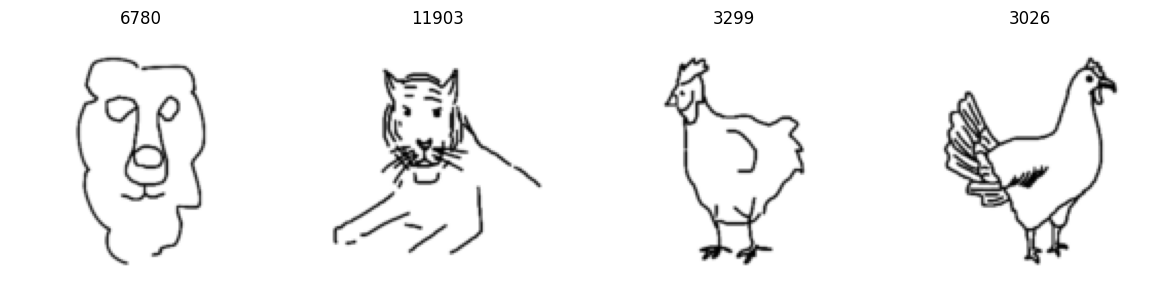

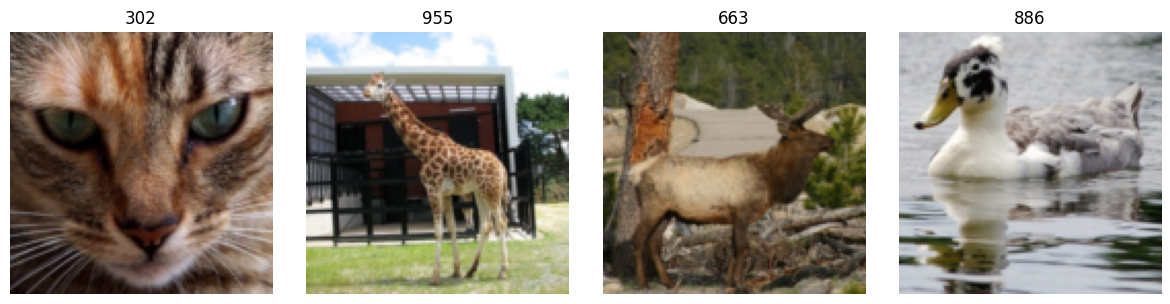

In [5]:
import random
import matplotlib.pyplot as plt

def un_normalize(tensor):
    return tensor * 0.5 + 0.5

def show(dataset, idx=None):
    idxs = [idx] if idx is not None else random.sample(range(len(dataset)), 4)
    if isinstance(idxs, int):
        idxs = [idxs]
    
    fig, axes = plt.subplots(1, len(idxs), figsize=(3*len(idxs), 3))
    if len(idxs) == 1:
        axes = [axes]
    
    for i, ix in enumerate(idxs):
        if ix >= len(dataset):
            ix = random.randint(0, len(dataset)-1)
        img = un_normalize(dataset[ix][0]).permute(1,2,0).numpy()
        axes[i].imshow(img)
        axes[i].set_title(f"{ix}")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

# Usage
show(sketch_dataset)  
show(photo_dataset)  

### Data Loading

In [20]:
from torchvision import datasets, transforms
import torch


IMAGE_SIZE = 128
BATCH_SIZE = 32
NUM_WORKERS = 2  # Parallel data loading

# Filter subset of categories to increas training speed
SELECTED_CATS = [
    'deer', 'dolphin', 'rhinoceros', 
    'owl', 'tiger', 'giraffe', 
    'ape', 'sheep', 'bear', 'lion', 'parrot', 
    'cow', 'duck', 'bee', 'zebra', 'rabbit', 'cat'
]



# Apply the filter
sketch_dataset.samples = [s for s in sketch_dataset.samples if sketch_dataset.classes[s[1]] in SELECTED_CATS]
photo_dataset.samples = [s for s in photo_dataset.samples if photo_dataset.classes[s[1]] in SELECTED_CATS]

sketch_loader = torch.utils.data.DataLoader(
    sketch_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True
)

photo_loader = torch.utils.data.DataLoader(
    photo_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True
)

print(f"Dataset Ready: {len(sketch_dataset)} sketches and {len(photo_dataset)} photos across {len(SELECTED_CATS)} categories.")

Dataset Ready: 11165 sketches and 1700 photos across 17 categories.


# Modeling

In [21]:
import torch
import torch.nn as nn

NC = 3               
NUM_RES_BLOCKS = 6   
BASE_FILTERS = 64     # Starting number of filters in the first convolutional layer

In [10]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, kernel_size=3),
            nn.InstanceNorm2d(channels),
            nn.ReLU(inplace=True),
            
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, kernel_size=3),
            nn.InstanceNorm2d(channels)
        )

    def forward(self, x):
        return x + self.block(x) 

In [11]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        # Downsampling
        self.encoder = nn.Sequential(
            nn.ReflectionPad2d(3),
            nn.Conv2d(NC, BASE_FILTERS, kernel_size=7),
            nn.InstanceNorm2d(BASE_FILTERS),
            nn.ReLU(inplace=True),

            # 128 -> 64
            nn.Conv2d(BASE_FILTERS, BASE_FILTERS*2, kernel_size=3, stride=2, padding=1),
            nn.InstanceNorm2d(BASE_FILTERS),
            nn.ReLU(inplace=True),

            # 64 -> 32
            nn.Conv2d(BASE_FILTERS * 2, BASE_FILTERS * 4, kernel_size=3, stride=2, padding=1),
            nn.InstanceNorm2d(BASE_FILTERS * 4),
            nn.ReLU(inplace=True)
        )

        # Transformer
        res_blocks = []
        for _ in range(NUM_RES_BLOCKS):
            res_blocks.append(ResidualBlock(BASE_FILTERS * 4))
        self.transformer = nn.Sequential(*res_blocks)

        # Up-sampling 
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(BASE_FILTERS * 4, BASE_FILTERS * 2, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.InstanceNorm2d(BASE_FILTERS * 2),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(BASE_FILTERS * 2, BASE_FILTERS, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.InstanceNorm2d(BASE_FILTERS),
            nn.ReLU(inplace=True),

            # Final Output Layer (Map back to 3 RGB channels)
            nn.ReflectionPad2d(3),
            nn.Conv2d(BASE_FILTERS, NC, kernel_size=7),
            nn.Tanh() # Squeezes pixel values between [-1, 1]
        )
        
    def forward(self, x):
        x = self.encoder(x)
        x = self.transformer(x)
        x = self.decoder(x)
        return x
            

In [12]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.model = nn.Sequential(
            # Layer 1
            nn.Conv2d(NC, BASE_FILTERS, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Layer 2
            nn.Conv2d(BASE_FILTERS, BASE_FILTERS * 2, kernel_size=4, stride=2, padding=1),
            nn.InstanceNorm2d(BASE_FILTERS * 2),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Layer 3
            nn.Conv2d(BASE_FILTERS * 2, BASE_FILTERS * 4, kernel_size=4, stride=2, padding=1),
            nn.InstanceNorm2d(BASE_FILTERS * 4),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Layer 4 
            nn.ZeroPad2d((1, 0, 1, 0)), 
            nn.Conv2d(BASE_FILTERS * 4, BASE_FILTERS * 8, kernel_size=4, padding=1),
            nn.InstanceNorm2d(BASE_FILTERS * 8),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Final Output Layer
            nn.Conv2d(BASE_FILTERS * 8, 1, kernel_size=4, padding=1)
        )

    def forward(self, x):
        return self.model(x)

In [22]:
def weights_init_normal(m):
    classname = m.__class__.__name__
    
    # Initialize Convolutional layers
    if "Conv" in classname:
        torch.nn.init.normal_(m.weight.data, 0.0, 0.02)
        if hasattr(m, "bias") and m.bias is not None:
            torch.nn.init.constant_(m.bias.data, 0.0)
            
    # Initialize Normalization layers (Only if they have learnable weights)
    elif "InstanceNorm" in classname:
        if m.weight is not None:
            torch.nn.init.normal_(m.weight.data, 1.0, 0.02)
        if m.bias is not None:
            torch.nn.init.constant_(m.bias.data, 0.0)

# Training

In [23]:
import torch.optim as optim
from torch.amp import autocast, GradScaler
from tqdm import tqdm 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize Models
G_AB = Generator().to(device)
G_BA = Generator().to(device)
D_A = Discriminator().to(device)
D_B = Discriminator().to(device)

# Apply random weights 
G_AB.apply(weights_init_normal)
G_BA.apply(weights_init_normal)
D_A.apply(weights_init_normal)
D_B.apply(weights_init_normal)

# Loss Functions
criterion_GAN = nn.MSELoss()
criterion_cycle = nn.L1Loss()
criterion_identity = nn.L1Loss()

# Optimizers 
LR = 0.0002
optimizer_G = optim.Adam(list(G_AB.parameters()) + list(G_BA.parameters()), lr=LR, betas=(0.5, 0.999))
optimizer_D_A = optim.Adam(D_A.parameters(), lr=LR, betas=(0.5, 0.999))
optimizer_D_B = optim.Adam(D_B.parameters(), lr=LR, betas=(0.5, 0.999))

scaler = GradScaler('cuda')

EPOCHS = 20

In [24]:
from torchmetrics.image import StructuralSimilarityIndexMeasure, PeakSignalNoiseRatio

ssim_metric = StructuralSimilarityIndexMeasure(data_range=2.0).to(device)
psnr_metric = PeakSignalNoiseRatio(data_range=2.0).to(device)

In [25]:
# Lists to store metrics for plotting
loss_history = {
    "gen_loss": [], "disc_loss": [],
    "cycle_loss": [], "identity_loss": [],
    "ssim": [], "psnr": []
}

In [26]:
from itertools import cycle # Added import

# Training Loop
for epoch in range(EPOCHS):
    # Wrap photo_loader in cycle() to loop the smaller dataset
    loop = tqdm(zip(sketch_loader, cycle(photo_loader)), total=len(sketch_loader), leave=True)
    
    # Variables to track average metrics per epoch
    epoch_ssim, epoch_psnr = 0.0, 0.0 
    epoch_gen_loss, epoch_disc_loss = 0.0, 0.0
    epoch_cycle_loss, epoch_id_loss = 0.0, 0.0
    
    for idx, ((real_A, _), (real_B, _)) in enumerate(loop):
        
        real_A = real_A.to(device) # Sketch
        real_B = real_B.to(device) # Photo
        
        # PatchGAN Output Labels (1, 0)
        patch_shape = D_A(real_A).shape
        valid = torch.ones(patch_shape, requires_grad=False).to(device)
        fake = torch.zeros(patch_shape, requires_grad=False).to(device)

        # TRAIN GENERATORS
        optimizer_G.zero_grad()

        with autocast(device_type=device.type): # Mixed precision context
            # Identity Loss 
            id_loss_A = criterion_identity(G_BA(real_A), real_A)
            id_loss_B = criterion_identity(G_AB(real_B), real_B)
            loss_identity = (id_loss_A + id_loss_B) / 2
            
            # GAN Loss
            fake_B = G_AB(real_A)  # Translate Sketch -> Photo
            fake_A = G_BA(real_B)  # Translate Photo -> Sketch
            
            loss_GAN_AB = criterion_GAN(D_B(fake_B), valid) 
            loss_GAN_BA = criterion_GAN(D_A(fake_A), valid)
            loss_GAN = (loss_GAN_AB + loss_GAN_BA) / 2
            
            # Cycle Loss
            recov_A = G_BA(fake_B)
            recov_B = G_AB(fake_A)
            
            loss_cycle_A = criterion_cycle(recov_A, real_A)
            loss_cycle_B = criterion_cycle(recov_B, real_B)
            loss_cycle = (loss_cycle_A + loss_cycle_B) / 2
            
            # Total Generator Loss
            loss_G = loss_GAN + (10.0 * loss_cycle) + (5.0 * loss_identity)
            
        # Backpropagation (Generators)
        scaler.scale(loss_G).backward()
        scaler.step(optimizer_G)

        # Calculate Metrics (SSIM & PSNR)
        current_ssim = ssim_metric(recov_B.detach(), real_B.detach())
        current_psnr = psnr_metric(recov_B.detach(), real_B.detach())
        epoch_ssim += current_ssim.item()
        epoch_psnr += current_psnr.item()

        # TRAIN DISCRIMINATORS
        
        # Discriminator A (Judges Sketches)
        optimizer_D_A.zero_grad()
        with autocast(device_type=device.type):
            loss_real_A = criterion_GAN(D_A(real_A), valid)
            loss_fake_A = criterion_GAN(D_A(fake_A.detach()), fake) 
            loss_D_A = (loss_real_A + loss_fake_A) / 2
            
        scaler.scale(loss_D_A).backward()
        scaler.step(optimizer_D_A)
        
        # Discriminator B (Judges Photos)
        optimizer_D_B.zero_grad()
        with autocast(device_type=device.type):
            loss_real_B = criterion_GAN(D_B(real_B), valid)
            loss_fake_B = criterion_GAN(D_B(fake_B.detach()), fake)
            loss_D_B = (loss_real_B + loss_fake_B) / 2
            
        scaler.scale(loss_D_B).backward()
        scaler.step(optimizer_D_B)
        
        scaler.update()

        # Track batch losses
        epoch_gen_loss += loss_G.item()
        epoch_disc_loss += (loss_D_A.item() + loss_D_B.item()) / 2
        epoch_cycle_loss += loss_cycle.item()
        epoch_id_loss += loss_identity.item()
        
        # PROGRESS BAR
        loop.set_description(f"Epoch [{epoch+1}/{EPOCHS}]")
        # SSIM and PSNR in live output
        loop.set_postfix(
            loss_G=loss_G.item(), 
            loss_D=(loss_D_A.item() + loss_D_B.item())/2,
            ssim=current_ssim.item(),
            psnr=current_psnr.item()
        )

    # Store Average losses
    num_batches = len(sketch_loader)
    loss_history["gen_loss"].append(epoch_gen_loss / num_batches)
    loss_history["disc_loss"].append(epoch_disc_loss / num_batches)
    loss_history["cycle_loss"].append(epoch_cycle_loss / num_batches)
    loss_history["identity_loss"].append(epoch_id_loss / num_batches)
    loss_history["ssim"].append(epoch_ssim / num_batches)
    loss_history["psnr"].append(epoch_psnr / num_batches)

Epoch [20/20]: 100%|██████████| 348/348 [08:24<00:00,  1.45s/it, loss_D=0.133, loss_G=1.4, psnr=23, ssim=0.641]    


In [27]:
import os
os.makedirs("checkpoints", exist_ok=True)
os.makedirs("samples", exist_ok=True)

In [28]:
import shutil

# This will compress your entire working directory into one neat zip file
shutil.make_archive("cyclegan_final_output", 'zip', "/kaggle/working/")
print("Zipping complete! Download cyclegan_final_output.zip from the right panel.")

Zipping complete! Download cyclegan_final_output.zip from the right panel.


In [29]:
def save_checkpoint(epoch, G_AB, G_BA, D_A, D_B, opt_G, opt_D_A, opt_D_B, loss_history, filename="checkpoint.pth"):
    checkpoint = {
        "epoch": epoch,
        "G_AB_state_dict": G_AB.state_dict(),
        "G_BA_state_dict": G_BA.state_dict(),
        "D_A_state_dict": D_A.state_dict(),
        "D_B_state_dict": D_B.state_dict(),
        "optimizer_G_state": opt_G.state_dict(),
        "optimizer_D_A_state": opt_D_A.state_dict(),
        "optimizer_D_B_state": opt_D_B.state_dict(),
        "loss_history": loss_history
    }
    torch.save(checkpoint, f"checkpoints/{filename}")
    # Also save the history as a JSON for easy reading without loading tensors
    with open("history.json", "w") as f:
        json.dump(loss_history, f)
    print(f"Checkpoint saved at Epoch {epoch+1}")

# Evaluation

In [74]:

def display_training_graphs(loss_history):
    epochs = range(1, len(loss_history["gen_loss"]) + 1)
    
    #  Adversarial Losses (Generator vs Discriminator)
    plt.figure(figsize=(10, 4))
    plt.plot(epochs, loss_history["gen_loss"], label="Generator Loss", color="blue", linewidth=2)
    plt.plot(epochs, loss_history["disc_loss"], label="Discriminator Loss", color="red", linewidth=2)
    plt.title("Adversarial Losses (GAN Loss)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss (MSE)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.show() # Displays the figure and starts a new one

    #  Structural Losses (Cycle & Identity)
    plt.figure(figsize=(10, 4))
    plt.plot(epochs, loss_history["cycle_loss"], label="Cycle Loss", color="green", linewidth=2)
    plt.plot(epochs, loss_history["identity_loss"], label="Identity Loss", color="purple", linewidth=2)
    plt.title("Structural Preservation (Cycle & Identity)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss (L1)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.show()

    # SSIM (Structural Similarity Index)
    plt.figure(figsize=(10, 4))
    plt.plot(epochs, loss_history["ssim"], label="SSIM", color="darkorange", linewidth=2)
    plt.title("Structural Similarity Index (SSIM)")
    plt.xlabel("Epoch")
    plt.ylabel("Score (Closer to 1.0 is better)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.show()

    # PSNR (Peak Signal-to-Noise Ratio)
    plt.figure(figsize=(10, 4))
    plt.plot(epochs, loss_history["psnr"], label="PSNR", color="brown", linewidth=2)
    plt.title("Peak Signal-to-Noise Ratio (PSNR)")
    plt.xlabel("Epoch")
    plt.ylabel("Score in dB (Higher is better)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.show()

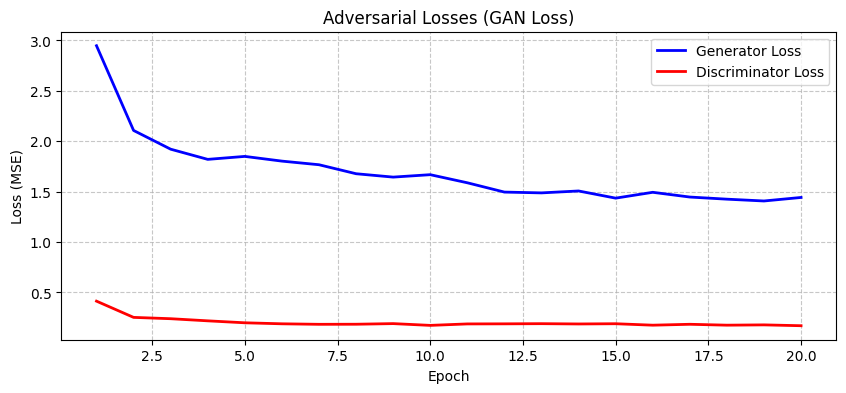

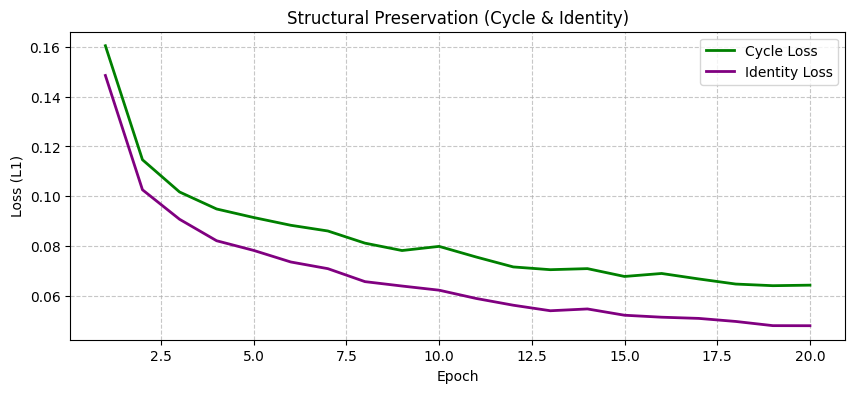

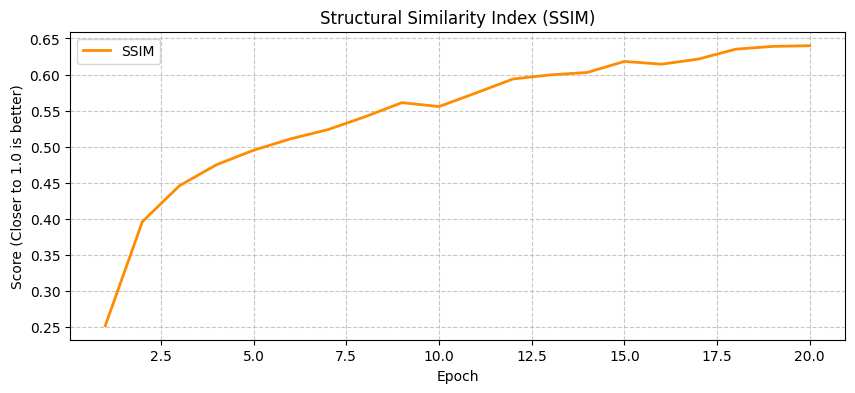

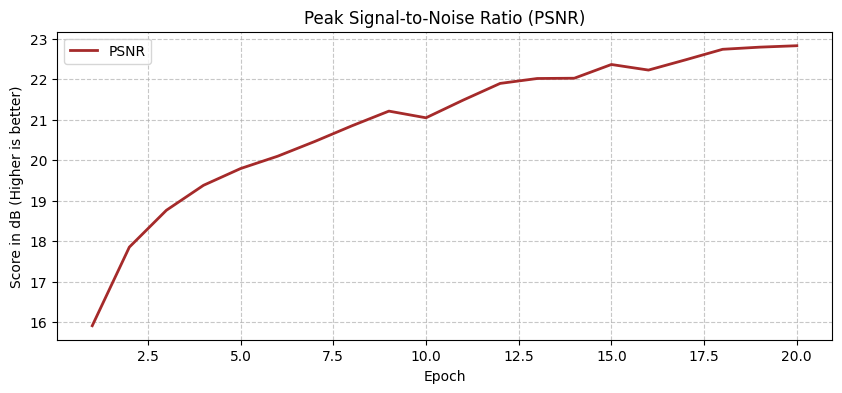

In [75]:
display_training_graphs(loss_history)

# Inference

In [32]:
import random
import torchvision.utils as utils


def visualize_translation(dataloader, generator, device, direction="Sketch → Photo", num_images=4, specific_idx=None):
    generator.eval()
    
    # Fetch the Data
    if specific_idx is not None:
        # Access the dataset directly to grab a specific index
        dataset = dataloader.dataset
        if specific_idx >= len(dataset):
            print(f"Error: Index {specific_idx} is out of bounds for dataset of size {len(dataset)}.")
            return
            
        real_img, _ = dataset[specific_idx]
        real_images = real_img.unsqueeze(0).to(device)
        num_images = 1
    else:
        # Grab a random shuffled batch from the loader
        real_images, _ = next(iter(dataloader))
        real_images = real_images[:num_images].to(device)
        
    with torch.no_grad():
        fake_images = generator(real_images)
        
    def denorm(x):
        return x * 0.5 + 0.5
        
    #  Visualization Grid
    comparison = torch.cat((denorm(real_images), denorm(fake_images)), dim=2)
    grid = utils.make_grid(comparison, nrow=num_images, padding=4, pad_value=1.0)
    
    # Scale figure size dynamically based on how many images we are showing
    plt.figure(figsize=(4 * num_images, 8)) 
    plt.imshow(grid.cpu().permute(1, 2, 0))
    plt.axis('off')
    plt.title(f"Translation: {direction}", fontsize=16)
    plt.show()


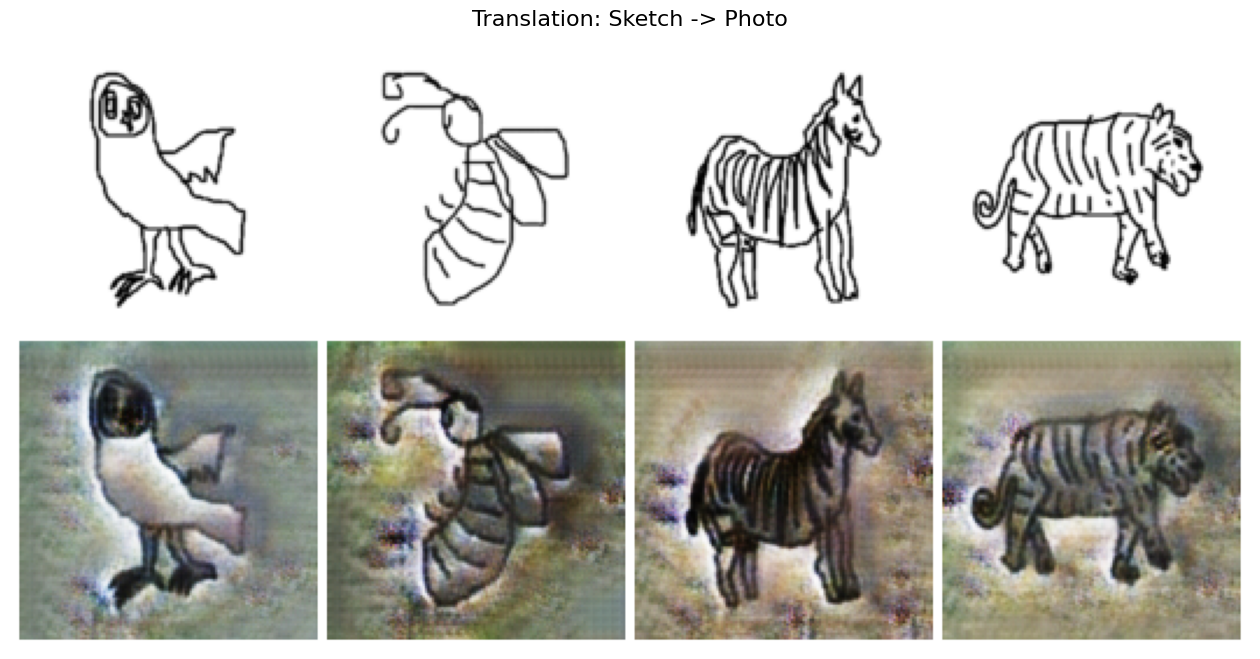

In [46]:
visualize_translation(
    dataloader=sketch_loader, 
    generator=G_AB, 
    device=device, 
    direction="Sketch -> Photo", 
    num_images=4
)

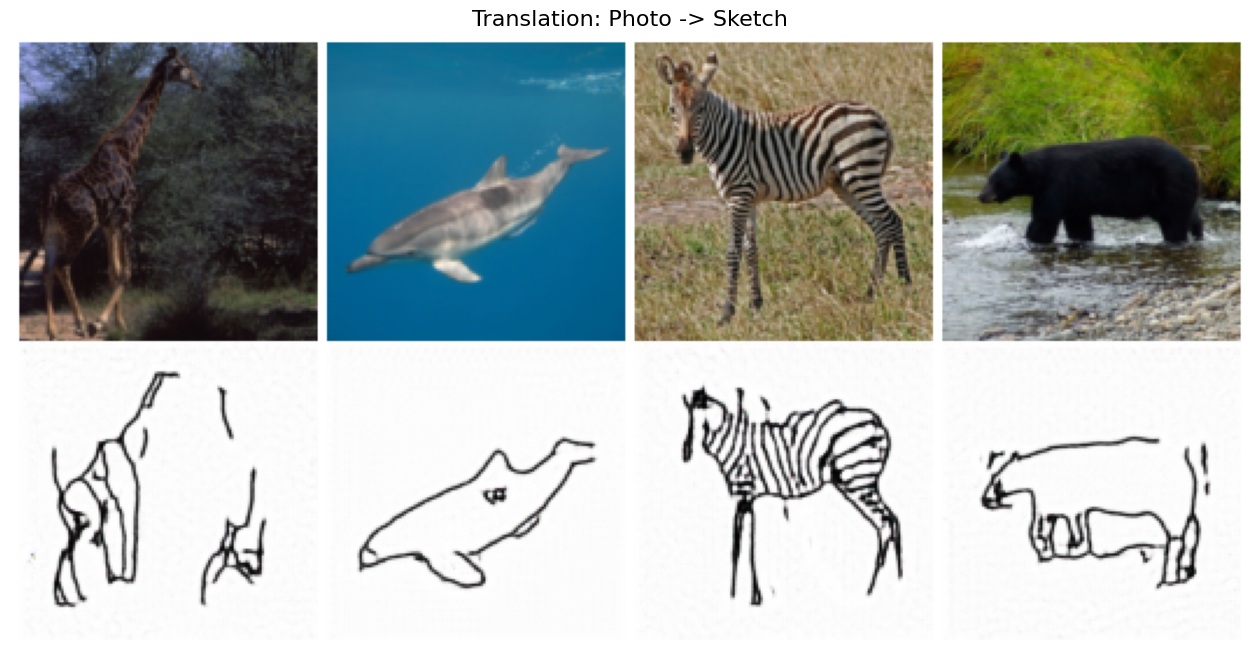

In [45]:
visualize_translation(
    dataloader=photo_loader, 
    generator=G_BA, 
    device=device, 
    direction="Photo -> Sketch", 
    num_images=4
)

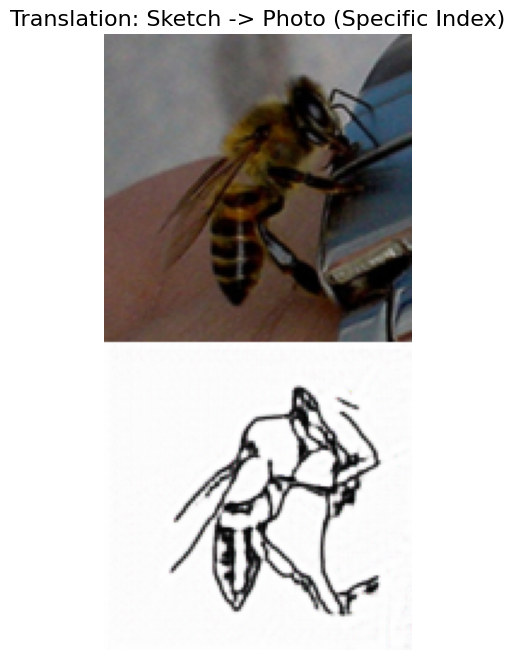

In [66]:
visualize_translation(
    dataloader=photo_loader, 
    generator=G_BA, 
    device=device, 
    direction="Sketch -> Photo (Specific Index)", 
    specific_idx=230
)

---

Future improvements will focus on scaling the training duration to higher epochs with a linear learning rate decay to further sharpen high-frequency textures. Additionally, Vision Transformer (ViT) backbone can be integrated within the generator to better capture long-range dependencies and improving the global coherence of complex sketches. Finally, the model can be optimized for real-time inference and deployed via a robust web interface for interactive user testing.